# The proposal
The idea is derived from the knn classifier - closser distance have similar answers.. As marked with the previous work. The major issue that I was facing when converting the classifier to supervised was that fft needs whole domain to be considered and so is not always computationally feasible as it will be like compressing the training dataset and decompressing it to refer again- which does not solve the problem of computational expense.. Fourier Series provide a way to reduce and extract only at required values but the feasibilty again ceases when considering higher dimensions. Gaussian model/KNN can provide interpolation over the domain but that does not solve the root problem.

## The proposed idea::

The idea is to reduce the dimentionality of input to such a degree that fourier series or any such functional apporximation become feasible computationally.. The key point that such a dimentional reducer must hold is that points that are closser to each other in higher dimentions are mapped to simmilar values in the reduced dimension space and also such mapping is proxy for hash/is unique so we dont have distinct points to be mapped to simmilar values..

While it is hard to find such a map and also such a map/kernel can be far optimized based on specific task. Here I have tried implementing a simple map - it considers the distance from the origin and a proxy for orientation on the hypersphere to produce a unique value..



In [15]:
import numpy as np
import functools
import operator
# !python -m pip install pandas
from sympy import fourier_series
import numpy as np
import pandas as pd
from sympy import fourier_series, pi

import matplotlib.pyplot as plt

import sklearn.datasets
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KDTree

from keras.datasets import cifar10
from keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.datasets import mnist
def mapd(x,y=1):
    def m1(x):
#         print(x)
        return np.polyval(x,0.01j)
    def m2(x):
        return np.polyval(x,-0.01j)
    return y*(np.array(list(map(m1,x))) - 1j*np.array(list(map(m1,x))))+x.sum(axis=1)
    sd = ((np.array(list(map(m1,x))) + np.array(list(map(m2,x)))))*((np.array(list(map(m1,x))) - np.array(list(map(m2,x)))))
    pp = np.linalg.norm(x,axis=1)## the power seems to inert the category values graph around 1
    print(x.shape,sd.shape)
    return (-1*(sd+pp*1j)**2).real#np.array(list(map(m2,sd+pp*1j)))#np.polyval(x,sd+pp*1j)#(np.log(((((pp))+(((sd)**1)))*(((pp))*(((sd)**1))))))#(1/((pp)*abs(sd)-pp))## after many trials reduce this number if there are a lot of categories else keep it high
    return ((abs(pp))*abs(sd)/abs(sd)**(1/((pp)*abs(sd)-pp)))## inverting about 1 as singularity and logging it as graph was exploding in values
    return abs(sd)**(1/((pp)*abs(sd)-pp))

To test wheather the function is a good proxy for the required map, we test if closer points are mapped to simmilar values and output space or the map is fairly one to one.

In [14]:
# !python -m pip install numpy  --upgrade
# !python -m pip install pandas  --upgrade
# !python -m pip install matplotlib  --upgrade
# !python -m pip install scikit-learn  --upgrade
# !python -m pip install scipy  --upgrade
# !python -m pip install plotly  --upgrade


  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/1a/2e/151484f49fd03944c4a3ad9c418ed193cfd02724e138ac8a9505d056c582/numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.8/114.8 kB 2.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 20.0 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.2
    Uninstalling numpy-1.26.2:
      Successfully uninstalled numpy-1.26.2
  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/21/d4/e6c57acc61e59cd46acca27af1f400094d5dee218e372cc604b8162b97cb/scipy-1.12.0-cp311-cp311-macosx_12_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.4/165.4 kB 2.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 18.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1

In [16]:
print("We take x and some random deviations around it and check their values with getting closser to x in next round")
x = np.array([1,4,0,4,2,4])
print("x",x)
x1 = x + np.random.random((x.shape[-1],5)).T
x2 = x + np.random.random((x.shape[-1],5)).T/10
x3 = x + np.random.random((x.shape[-1],5)).T/100
x = x + np.zeros((x.shape[-1],5)).T
print(mapd(x))
print("_____")
print(mapd(x1))
print("_____")
print(mapd(x2))
print("_____")
print(mapd(x3))
print("Clearly as the values get closer the output space gets closer")

print("\n\n\n")

x = np.array([-1,4,0,4,2,4])
print("x",x)
x1 = x + np.random.random((x.shape[-1],5)).T
x2 = x + np.random.random((x.shape[-1],5)).T/10
x3 = x + np.random.random((x.shape[-1],5)).T/100
x = x + np.zeros((x.shape[-1],5)).T
print(mapd(x))
print("_____")
print(mapd(x1))
print("_____")
print(mapd(x2))
print("_____")
print(mapd(x3))

print("\n\n\n")


x = np.array([1,4,1,4,2,4])
print("x",x)
x1 = x + np.random.random((x.shape[-1],5)).T
x2 = x + np.random.random((x.shape[-1],5)).T/10
x3 = x + np.random.random((x.shape[-1],5)).T/100
x = x + np.zeros((x.shape[-1],5)).T
print(mapd(x))
print("_____")
print(mapd(x1))
print("_____")
print(mapd(x2))
print("_____")
print(mapd(x3))


print("\n\n\n")


x = np.array([1,-4,0,4,2,4])
print("x",x)
x1 = x + np.random.random((x.shape[-1],5)).T
x2 = x + np.random.random((x.shape[-1],5)).T/10
x3 = x + np.random.random((x.shape[-1],5)).T/100
x = x + np.zeros((x.shape[-1],5)).T
print(mapd(x))
print("_____")
print(mapd(x1))
print("_____")
print(mapd(x2))
print("_____")
print(mapd(x3))


print("\n\n\n")


x = np.array([1,4,0,-7,2,4])
print("x",x)
x1 = x + np.random.random((x.shape[-1],5)).T
x2 = x + np.random.random((x.shape[-1],5)).T/10
x3 = x + np.random.random((x.shape[-1],5)).T/100
x = x + np.zeros((x.shape[-1],5)).T
print(mapd(x))
print("_____")
print(mapd(x1))
print("_____")
print(mapd(x2))
print("_____")
print(mapd(x3))
print("\n\n")

print("Different values are mapped uniquely")

We take x and some random deviations around it and check their values with getting closser to x in next round
x [1 4 0 4 2 4]
[19.01960004-3.97960004j 19.01960004-3.97960004j 19.01960004-3.97960004j
 19.01960004-3.97960004j 19.01960004-3.97960004j]
_____
[22.09958671-4.46758052j 22.13509346-4.3523047j  23.08040497-4.35445657j
 22.28953457-4.09022454j 22.14880355-4.3359272j ]
_____
[19.54917973-4.05705398j 19.44870918-4.05537577j 19.39001362-4.04012024j
 19.44700034-4.01618991j 19.46616859-4.07545954j]
_____
[19.06159354-3.98312915j 19.05318292-3.9822804j  19.05132543-3.9886739j
 19.04407843-3.98615723j 19.04385677-3.98296009j]
Clearly as the values get closer the output space gets closer




x [-1  4  0  4  2  4]
[17.01960004-3.97960004j 17.01960004-3.97960004j 17.01960004-3.97960004j
 17.01960004-3.97960004j 17.01960004-3.97960004j]
_____
[20.33987728-4.57585219j 20.68870741-4.29755853j 19.95265854-4.25935381j
 20.65906115-4.27191562j 19.49783286-4.49445596j]
_____
[17.39621744-4.0725

# Next
Once we have a kernel, we convert the training data to reduced dimensions and try to see if the idea of closeness of similar categories is captured with this

In [17]:
## Iris dataset
X, Y = sklearn.datasets.load_iris(return_X_y=True)
x_train,x_test,Y_train,Y_test = train_test_split(X,Y)

In [18]:
## We normalize the input for better mapping
xw = (x_train - x_train.mean(axis=0))/x_train.std(axis=0)
xx = mapd(x_train)
xx_ = mapd(x_test)
xx.shape,Y_train.shape

((112,), (112,))

In [19]:
xc = sorted(xx)
inid = list(range(len(xc)))
inid.sort(key = lambda x:xx[x])
yc = Y_train[inid]
xct = sorted(xx_)
inid = list(range(len(xct)))
inid.sort(key = lambda x:xx_[x])
yct = Y_test[inid]

/opt/homebrew/Caskroom/miniconda/base/envs/AI/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/Caskroom/miniconda/base/envs/AI/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/homebrew/Caskroom/miniconda/base/envs/AI/lib/python3.11/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


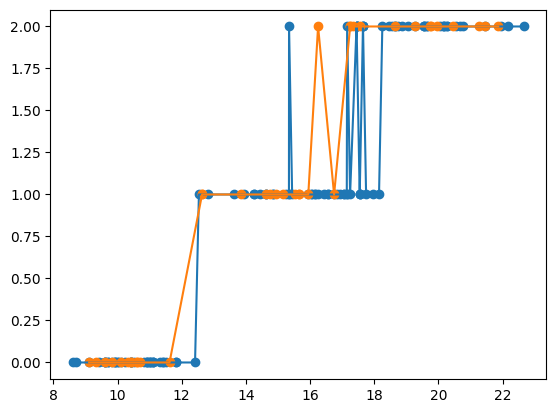

In [20]:
i = 0
plt.plot(xc[i:],yc[i:])
plt.scatter(xc[i:],yc[i:])
plt.plot(xct,yct)
plt.scatter(xct,yct)

# ##
The method seems to work for this dataset and then this single variable function be approximated as fourier series.
however the reduction map used is not the best and does not perform very great on different dataset.

In [21]:
X, Y = sklearn.datasets.fetch_openml("titanic", return_X_y=True, as_frame=False)
Y = (np.array(list(map(int,Y)))+1)/2
#X = np.array(data["data"])
#Y = np.where(data["target"]=="tested_positive",0,1)#np.array(list(map(list(data["target"]),lambda x: 1 if x == "tested_positive" else 0)))
x_train,x_test,Y_train,Y_test = train_test_split(X,Y)

/opt/homebrew/Caskroom/miniconda/base/envs/AI/lib/python3.11/site-packages/sklearn/datasets/_openml.py:322: UserWarning: Multiple active versions of the dataset matching the name titanic exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=40704
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=40945

  warn(warning_msg)


In [22]:
xw = (x_train - x_train.mean(axis=0))/x_train.std(axis=0)
xx = mapd(x_train)
xx_ = mapd(x_test)
xx = xx.real
xx_ = xx_.real
xx.shape,Y_train.shape

((1650,), (1650,))

In [23]:


xc = sorted(xx)
inid = list(range(len(xc)))
inid.sort(key = lambda x:xx[x])
yc = Y_train[inid]
xct = sorted(xx_)
inid = list(range(len(xct)))
inid.sort(key = lambda x:xx_[x])
yct = Y_test[inid]

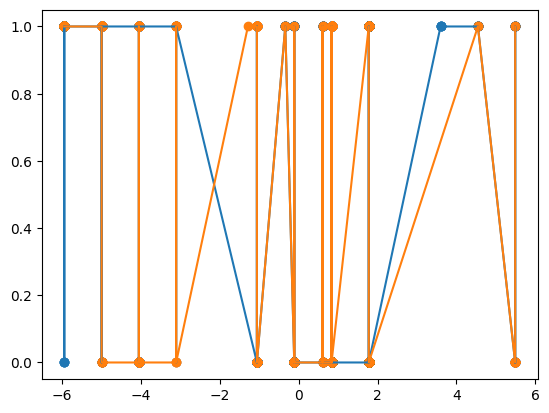

In [24]:
i = 0
plt.plot(xc[i:],yc[i:])
plt.scatter(xc[i:],yc[i:])
plt.plot(xct,yct)
plt.scatter(xct,yct)

### Update
After considering some aspects I noted that it does not perform well in some datasets is because of the presence of outliers that or false dataset.. to fix this I shall consider only that value as the output that has the maximum number of samples in the training dataset,,

In [25]:
X, Y = sklearn.datasets.fetch_openml("titanic", return_X_y=True, as_frame=False)
x_train,x_test,Y_train,Y_test = train_test_split(X,Y)
xw = (x_train - x_train.mean(axis=0))/x_train.std(axis=0)
xx = mapd(x_train*10)
xx_ = mapd(x_test*10)
xx = xx.real
xx_ = xx_.real
xx.shape,Y_train.shape
xc = sorted(xx)
inid = list(range(len(xc)))
inid.sort(key = lambda x:xx[x])
yc = list(map(int,(Y_train[inid])))
xct = sorted(xx_)
inid = list(range(len(xct)))
inid.sort(key = lambda x:xx_[x])
yct = list(map(int,Y_test[inid]))

/opt/homebrew/Caskroom/miniconda/base/envs/AI/lib/python3.11/site-packages/sklearn/datasets/_openml.py:322: UserWarning: Multiple active versions of the dataset matching the name titanic exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=40704
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=40945

  warn(warning_msg)


In [26]:
uniqueDict = {}
for i in range(len(xc)):
    uniqueDict[xc[i]] = []
for i in range(len(xc)):
    uniqueDict[xc[i]].append(yc[i])
for i in uniqueDict:
    uniqueDict[i]=np.array(uniqueDict[i]).mean()
yc_ = []
for i in xc:
    yc_.append(uniqueDict[i])
uniqueDict = {}
for i in range(len(xct)):
    uniqueDict[xct[i]] = []
for i in range(len(xct)):
    uniqueDict[xct[i]].append(yct[i])
for i in uniqueDict:
    uniqueDict[i]=np.array(uniqueDict[i]).mean()
yct_ = []
for i in xct:
    yct_.append(uniqueDict[i])

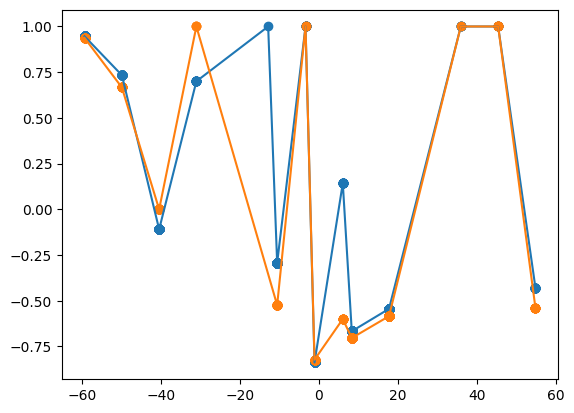

In [27]:
i = 0
plt.plot(xc[i:],yc_[i:])
plt.scatter(xc[i:],yc_[i:])
plt.plot(xct,yct_)
plt.scatter(xct,yct_)

# Conclusion
This seems to be a much better fit..
Now we can proceed to fit it using some functional approximation for lower dimentions..
For now I am going to try fourier series

In [110]:
## using the earlier made interpolation function
def interpolt(X,Y,inpus):
    inpus = np.array(inpus).reshape(-1,)
    Ans = []
    for inp in inpus:
        inpu = np.array([inp]).reshape(-1,1)
        Y = Y.reshape(-1,1)#,np.array([[1 for i in range(len(X[0]))]]))
        xx = (X[1:]-X[:-1]).reshape(-1,1)
        yy = Y[1:]-Y[:-1]
        tt = (yy/xx**1.1)#.cumsum()
        t_ = 0*X
#         print(t_.shape,tt.shape)
        t_[1:-1] = ((tt[:-1]+tt[1:])/((np.pi-np.e)*2)/(1+0/xx[:-1]+0/xx[1:])).reshape(-1,X.shape[-1]-2)
        t_[0] = tt[0]
        t_[-1] = tt[-1]
        t_

        tree = KDTree(X.reshape(-1,1))
#         print(X,inpu,"sdss")
        distances, indices = tree.query(inpu,min(10,len(X)))
        #indices = [([indi,0]) for indi in indices]
        sd = [0]#[[0,1] for indi in indices]
#         print("sd")
#         print(indices)
#         print((X[indices]>inpu)[0])
        _2 = indices.reshape(-1,)[(X[indices[0]]>inpu)[0]]
        _2 = _2[0] if len(_2) else -1
        _1 = indices.reshape(-1,)[(X[indices[0]]<inpu).reshape(-1,)]
        _1 = _1[0] if len(_1) else 0

        if _1==_2:
            Ans.append(Y[_2][0])
            continue

        x1 = X[_1]
        x2 = X[_2]
        M = np.array([[x1**3,x1**2,x1,1],[x2**3,x2**2,x2,1],[3*x1**2,2*x1,1,0],[3*x2**2,2*x2,1,0]])
        Vec = np.array([Y[_1],Y[_2],t_[_1],t_[_2]])
        try:
            pp = np.dot(np.linalg.inv(M),Vec)
        except:
            Ans.append(Y[_2][0])
            continue
        Ans.append(np.polyval(pp,inpu)[0][0])
    return np.array(Ans)

def KNN_Classify(x_train,Y_train,inpus):

#     print(x_train[0])
    inpus = np.array(inpus).reshape(-1,1)%25
#     print(inpus)
    
    Ans = []
    n = len(x_train)
    filteTrain = [np.random.randint(0,x_train.shape[0],min(7000,int(n/1))).reshape(-1,)]
#     print(filteTrain, Y_train)
    
    X_train = x_train[filteTrain][0]
    y_train = Y_train[filteTrain][0]
#     print(X_train.shape, y_train)
    tree = KDTree(X_train)
    distances, indices = tree.query(inpus, k=min(700,int(n/3)))
#     print("treed")
    t = 0
#     print(len(inpus))
    for ii in range(len(inpus)):  
        inpu = inpus[ii]
        dis = distances[ii]
        bias = y_train.mean(axis=0)
        bb = bias.mean()
        k = 2*np.pi
        bias-=bb
        DD = ((1/(np.e**(k*dis)+1).reshape(-1,1))).sum()
#         print(DD)
#         print(t,"________________",t,flush=True)
        t+=1
        Ans.append((((y_train[indices[ii]])/((np.e**(k*dis)+1).reshape(-1,1))).sum(axis=0)/DD)-bias)
#         print(ii)
#     print(len(Ans),"aervev")
#     print(Ans)
    return Ans



In [111]:
## Iris dataset
X, Y = sklearn.datasets.load_iris(return_X_y=True)
x_train,x_test,Y_train,Y_test = train_test_split(X,Y)

## We normalize the input for better mapping
xw = (x_train - x_train.mean(axis=0))/x_train.std(axis=0)
xx = mapd(x_train)
xx_ = mapd(x_test)
xx.shape,Y_train.shape

xc = sorted(xx)
inid = list(range(len(xc)))
inid.sort(key = lambda x:xx[x])
yc = Y_train[inid]
xct = sorted(xx_)
inid = list(range(len(xct)))
inid.sort(key = lambda x:xx_[x])
yct = Y_test[inid]
xc = np.array(xc)
yc = np.array(yc)

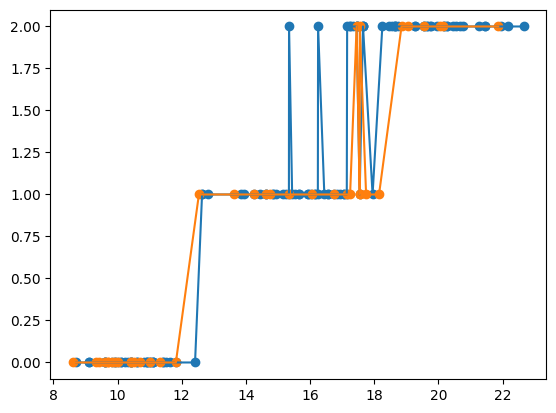

In [112]:

plt.plot(xc,yc)
plt.scatter(xc,yc)
plt.plot(xct,yct)
plt.scatter(xct,yct)

In [113]:
XX = xc.real

from sympy.abc import x
f = lambda t: interpolt(XX,np.array(yc).reshape(-1,1),[[t]])[0][0]
# interpolt(XX,yc,[[19]])[0][0]
KNN_Classify(XX.reshape(-1,1),np.array(yc).reshape(-1,),[[0]])[0][0]
XX.reshape(-1,1)[[1,0]]

array([[9.1126956],
       [8.7127655]])

In [114]:
xc.real.reshape(-1,1)

array([[ 8.7127655],
       [ 9.1126956],
       [ 9.1137056],
       [ 9.6126753],
       [ 9.6136754],
       [ 9.6146854],
       [ 9.811675 ],
       [ 9.9146851],
       [ 9.9156852],
       [10.0136554],
       [10.1136351],
       [10.113665 ],
       [10.2156552],
       [10.314655 ],
       [10.412645 ],
       [10.4136548],
       [10.4146549],
       [10.6136449],
       [10.6146448],
       [10.815655 ],
       [10.9146247],
       [10.9156149],
       [10.9166546],
       [11.0145848],
       [11.0146149],
       [11.1146249],
       [11.1146546],
       [11.1166649],
       [11.4115942],
       [11.4126046],
       [11.5135745],
       [11.6186149],
       [11.8166046],
       [12.4145543],
       [12.6327551],
       [12.632765 ],
       [12.8297449],
       [13.8347343],
       [13.9377545],
       [14.2387444],
       [14.4397645],
       [14.6387248],
       [14.6397445],
       [14.8387242],
       [14.8397342],
       [14.9437345],
       [15.1417244],
       [15.24

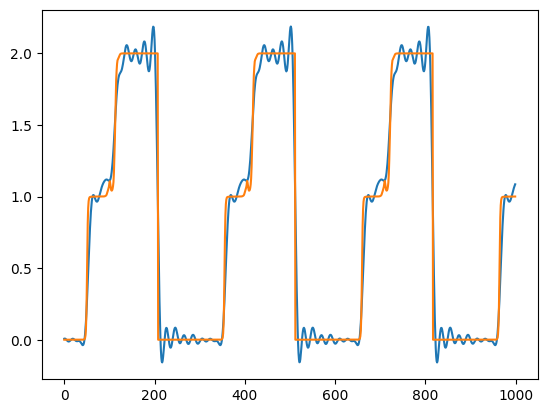

In [116]:
import numpy as np
import scipy.integrate as spi
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

#t is the independent variable
P = 25. #period value
BT=8. #initian value of t (begin time)
ET=90. #final value of t (end time)
FS=1000 #number of discrete values of t between BT and ET

#the periodic real-valued function f(t) with period equal to P
# f = lambda t: ((t % P) - (P / 2.)) ** 3
# f = lambda t: interpolt(XX,yc,[[t]])
f = lambda t: KNN_Classify(XX.reshape(-1,1),np.array(yc).reshape(-1,1),[[t]])
#all discrete values of t in the interval from BT and ET
t_range = np.linspace(BT, ET, FS)
y_true = f(t_range)

#the true f(t)

#function that computes the real fourier couples of coefficients (a0, 0), (a1, b1)...(aN, bN)
def compute_real_fourier_coeffs(func, N,P):
    result = []
    for n in range(N+1):
        an = (2./P) * spi.quad(lambda t: func(t)[0] * np.cos(2 * np.pi * n * t / P), 0, P)[0]
        bn = (2./P) * spi.quad(lambda t: func(t)[0] * np.sin(2 * np.pi * n * t / P), 0, P)[0]
        result.append((an, bn))
    return np.array(result)

#function that computes the real form Fourier series using an and bn coefficients
def fit_func_by_fourier_series_with_real_coeffs(t, AB):
    result = 0.
    A = AB[:,0]
    B = AB[:,1]
    for n in range(0, len(AB)):
        if n > 0:
            result +=  A[n] * np.cos(2. * np.pi * n * t / P) + B[n] * np.sin(2. * np.pi * n * t / P)
        else:
            result +=  A[0]/2.
    return result

AB = compute_real_fourier_coeffs(f, 15,25)
#AB contains the list of couples of (an, bn) coefficients for n in 1..N interval.

y_approx = fit_func_by_fourier_series_with_real_coeffs(t_range, AB)
plt.plot(y_approx)
plt.plot(y_true)

In [117]:
X_train

NameError: name 'X_train' is not defined

# Finalizing
The function seem to fit and work now we should package everything into one module and check metric performances

In [121]:
## Converting standardized Input to standard 1d
def conv(x_train):
    xw = (x_train - x_train.mean(axis=0))/x_train.std(axis=0)
    return mapd(x_train)

## sorting based on new mapped input
def sortItOut(xx,Y_train):
    xc = sorted(xx)
    inid = list(range(len(xc)))
    inid.sort(key = lambda x:xx[x])
    yc = Y_train[inid]
    xc = np.array(xc)
    yc = np.array(yc)
    return xc,yc

## unique map if there is more than one output
def uM(xc,yc):
    uniqueDict = {}
    for i in range(len(xc)):
        uniqueDict[xc[i]] = []
    for i in range(len(xc)):
        uniqueDict[xc[i]].append(yc[i])
    for i in uniqueDict:
        uniqueDict[i]=np.array(uniqueDict[i]).mean()
    yc_ = []
    for i in xc:
        
        yc_.append(uniqueDict[i])
    return xc, np.array(yc_)

## classifying interpolation algorithm:::
def KNN_Classify_(x_train,Y_train,inpus,P):
#     print(P)
#     print(x_train[0])
#     print((np.array(inpus).reshape(-1,1)),P)
    inpus = np.array(inpus).reshape(-1,1)%(round(P))
#     print(inpus)
    
    Ans = []
    n = len(x_train)
    filteTrain = [np.random.randint(0,x_train.shape[0],min(7000,int(n/1)))]
    X_train = x_train[filteTrain][0]
    y_train = Y_train[filteTrain][0]
    tree = KDTree(X_train)
    distances, indices = tree.query(inpus, k=min(700,int(n/3)))
#     print("treed")
    t = 0
#     print(len(inpus))
    for ii in range(len(inpus)):  
        inpu = inpus[ii]
        dis = distances[ii]
        bias = y_train.mean(axis=0)
        bb = bias.mean()
        k = 2*np.pi
        bias-=bb
        DD = ((1/(np.e**(k*dis)+1).reshape(-1,1))).sum()
#         print(DD)
#         print(t,"________________",t,flush=True)
        t+=1
        Ans.append((((y_train[indices[ii]])/((np.e**(k*dis)+1).reshape(-1,1))).sum(axis=0)/DD)-bias)
#         print(ii)
#     print(len(Ans),"aervev")
#     print(Ans)
    return Ans

### defining continuity function

def giveInterpolFunc(xc,yc):
    XX = xc.real
    f = lambda t: KNN_Classify_(XX.reshape(-1,1),np.array(yc).reshape(-1,1),[[t]],XX[-1])
    return f

### Converting to Supervised Parameters

def compute_real_fourier_coeffs(func, N, P):
    result = []
    for n in range(N+1):
        an = (2./P) * spi.quad(lambda t: func(t)[0] * np.cos(2 * np.pi * n * t / P), 0, P)[0]
        bn = (2./P) * spi.quad(lambda t: func(t)[0] * np.sin(2 * np.pi * n * t / P), 0, P)[0]
        result.append((an, bn))
    return np.array(result)

#function that computes the real form Fourier series using an and bn coefficients
def fit_func_by_fourier_series_with_real_coeffs(t, AB):
    result = 0.
    A = AB[:,0]
    B = AB[:,1]
    for n in range(0, len(AB)):
        if n > 0:
            result +=  A[n] * np.cos(2. * np.pi * n * t / P) + B[n] * np.sin(2. * np.pi * n * t / P)
        else:
            result +=  A[0]/2.
    return result
## Function that predicts the output for testing::
def predd(x_test,AB):
    xx = conv(x_test).real
    return fit_func_by_fourier_series_with_real_coeffs(xx,AB)

In [122]:
##3 To soothen out the whole process into just one function::

def reduceSupervised(x_train,Y_train,N=8):
    xx = conv(x_train)
    xc,yc = sortItOut(xx,Y_train)
    xc,yc = uM(xc,yc)
    f = giveInterpolFunc(xc,yc)
    return compute_real_fourier_coeffs(f,N,round(xc[-1].real))

In [123]:
## Iris dataset
X, Y = sklearn.datasets.load_iris(return_X_y=True)
x_train,x_test,Y_train,Y_test = train_test_split(X,Y)
AB = reduceSupervised(x_train,Y_train,25)

In [124]:
## predicting
y_pred = np.array(list(map(round,((predd(x_test,AB))))))

In [125]:
## accuracy
acc = 1 - (sum(abs(y_pred-Y_test)))/len(y_pred)
acc

0.8157894736842105

In [126]:
np.array([Y_test,y_pred]).T

array([[0, 0],
       [0, 0],
       [2, 2],
       [1, 1],
       [1, 1],
       [1, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [2, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [2, 2],
       [1, 1],
       [2, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [2, 2],
       [1, 1],
       [0, 0],
       [2, 1],
       [1, 1],
       [0, 0],
       [2, 1],
       [1, 1],
       [2, 2],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [2, 1]])

In [127]:
X, Y = sklearn.datasets.fetch_openml("titanic", return_X_y=True, as_frame=False)
x_train,x_test,Y_train,Y_test = train_test_split(X,Y)
Y_test = (np.array(list(map(int,Y_test)))+1)/2
Y_train = (np.array(list(map(int,Y_train)))+1)/2
AB = reduceSupervised(x_train,Y_train)

In [128]:
## predicting
y_pred = np.array(list(map(round,((predd(x_test,AB))))))

In [129]:
## accuracy
acc = 1 - (sum(abs(y_pred-Y_test)))/len(y_pred)
acc

0.7568058076225046

In [130]:
np.array([Y_test,y_pred]).T

array([[0., 0.],
       [0., 0.],
       [1., 0.],
       ...,
       [1., 1.],
       [1., 1.],
       [0., 0.]])

# Important Note
The categorization used here is in the form of numbers from 0 and this encoding matters as if -1/1 ecoding or 0/2 encoding is used then the accuracy decreases drastically.. however that is an issue of encoding and that can arise further if there are more categories like minst dataset. but for current requirement the goal is achieved..

# Conclusion
We were able to make a supervised learning model that requires least amount of trainning time yet gives good accuracy..